In [1]:
import numpy as np
from basics import load_images, convert_into_array, sort_data
from calibration import k_lambda_fit

# Calibration

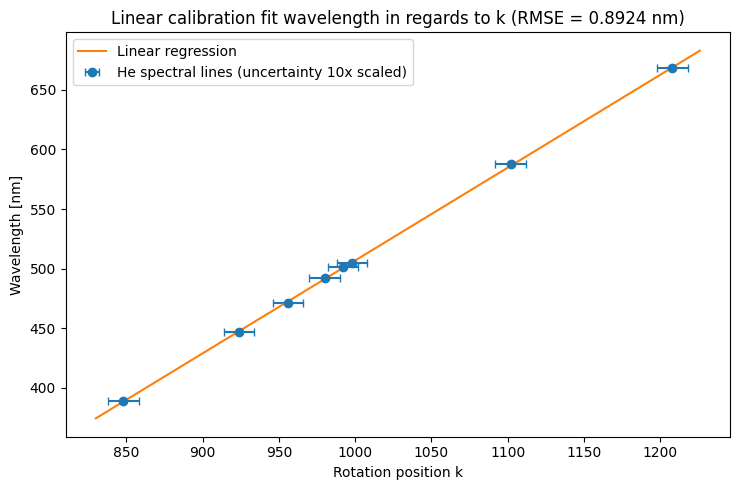

0.7781+/-0.0035 348.6+/-3.0


In [3]:
# relation k to lamda
path_k_lamda_Notizen = "C:/Users/Lorenz/Documents/Datenanalyse/P1/Spectroscopy_2/Notizen/"
path_k_lamda_Bilder = "C:/Users/Lorenz/Documents/Datenanalyse/P1/Spectroscopy_2/Bilder/k_lamda"
images_k_lamda = load_images(path_k_lamda_Bilder)
images_one_line_k_lambda, raw_one_line_k_lamda = convert_into_array(images_k_lamda)
img_dic_k_lambda = sort_data(path_k_lamda_Bilder, path_k_lamda_Notizen, images_one_line_k_lambda, "k-values")
He_spectrum = np.array([667.8,587.5,504.7,501.5,492.1,471.3,447.1,388.8])
k_measured_lamda = np.array([img_dic_k_lambda[name]['k_value'] for name in img_dic_k_lambda])

# sanity check
if len(He_spectrum) != len(k_measured_lamda):
    raise Exception("Zu viele oder zu wenig Linien detektiert :/")

# uncertainties
sigma_k_lambda = np.ones_like(k_measured_lamda) #adjust
sigma_lambda = None

# linear fit for relation, k and lamda
b, k0 = k_lambda_fit(He_spectrum, k_measured_lamda, sigma_k_lambda)
print(b,k0)